In [1]:

!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.4 MB/s eta 0:00:00


Variable to analyze (e.g. aceleracao x): aceleracao y
Define a time interval for the analysis? (y/n): n


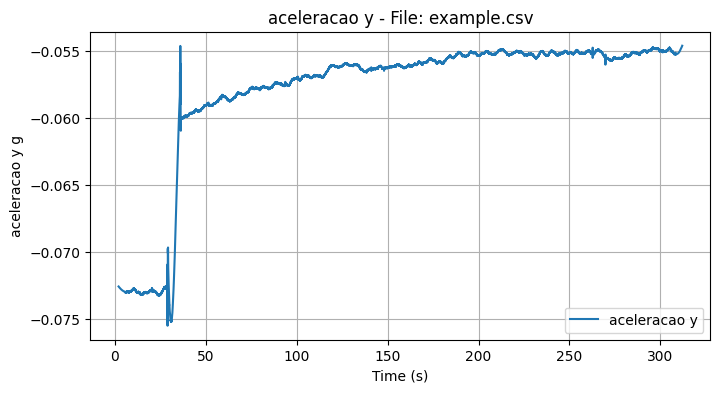

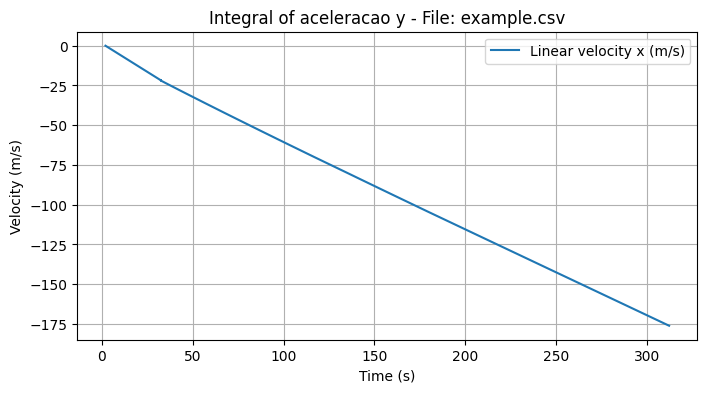

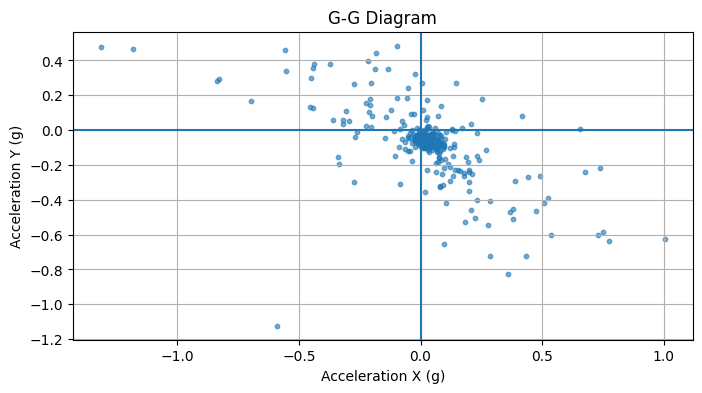

Report generated for aceleracao y
Mean acceleration: -0.058 g
Mean velocity: -9.313 (m/s)
Standard deviation: 0.014
Mean linear displacement: -988.714 (m)


In [ ]:
import io
import os
from io import BytesIO
from scipy.integrate import cumulative_trapezoid
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from google.colab import files
from google.colab import drive
import pandas as pd
import numpy as np
# %matplotlib inline
import importlib

from docx import Document
from docx.shared import Inches
doc = Document()

# Feature flags controlling which pipeline stages have been executed
montar_google_d = False
limites_ = False
intervalo_ = False
analise_graf = False
integral_ = False
diag_GG_ = False
dados_ = False
salvar_w = False

# Default measurement units
unidade_acel = 'g'
unidade_dist = 'm'
unidade_rot = 'rad'

pasta = "/content/sample_data" # Directory containing the CSV data files
arquivos_csv = [f for f in os.listdir(pasta) if f.endswith(".csv")] # Filter: only include CSV files
coluna_tempo = 'tempo de execucao'

# Corrects raw accelerometer readings to account for sensor placement offset
# relative to the vehicle's center of gravity.

def acel_corrigida(df):
  # Sensor position relative to the origin (center of gravity), in meters
  x = 0.44
  y = 0.035
  z = 0.23
  cm = np.array([730, 580, 350]) # Approximate center-of-gravity coordinates
  r_dtl = np.array([x, y, z]) # Approximate sensor coordinates
  r_rel = r_dtl - cm # Displacement vector from center of gravity to sensor

  t = df['tempo de execucao'].to_numpy() # Convert timestamps to a NumPy array
  ac_l = df[['aceleracao x', 'aceleracao y', 'aceleracao z']].to_numpy()

  giro_conv = np.deg2rad(df[['giroscopio x','giroscopio y','giroscopio z']].to_numpy())
  alpha = np.gradient(giro_conv, t, axis=0)

  ac_tangencial = np.cross(alpha, r_rel)
  # Tangential acceleration component, computed as the cross product of angular acceleration and displacement
  ac_centripeta = np.cross(giro_conv, np.cross(giro_conv, r_rel))
  # Centripetal acceleration component, computed as the double cross product of angular velocity and displacement

  ac_lc = ac_l - ac_tangencial - ac_centripeta
  # Corrected acceleration: raw measurement minus kinematic correction terms

  return ac_lc

def limites(): # Defines the time interval used for analysis
    var = 'Variável não definida'
    inic_intervalo = None
    fim_intervalo = None
    inic_ms = None
    fim_ms = None


    var = input('Variable to analyze (e.g. aceleracao x): ').strip()
    if not var:
        raise ValueError("A valid variable name is required.")
    intervalo = str(input("Define a time interval for the analysis? (y/n): ")).strip()
    if intervalo == 's':
      inic_intervalo = float(input("Start of interval (in minutes): ")) # Start of interval
      fim_intervalo = float(input("End of interval (in minutes): "))     # End of interval
      if fim_intervalo > 5.2:
        print("The maximum allowed end of interval is 5.2 minutes.")
        print("The end of the interval will be set to 5.2 minutes.")
        fim_intervalo = 5.2
      else:
        pass
    elif intervalo == 'n':
      inic_intervalo = 0
      fim_intervalo = 5.2
    else:
      print("Invalid interval selection.")

    inic_ms = inic_intervalo * 60 * 1000
    fim_ms = fim_intervalo * 60 * 1000

    # Convert from minutes (user input) to milliseconds (unit stored by the RTC)
    doc.add_paragraph("="*50)
    if intervalo == 's':
      doc.add_paragraph(f"Selected interval: {inic_intervalo} to {fim_intervalo} (minutes).")
      intervalo_ = True
    else:
      doc.add_paragraph("No valid time interval was selected for analysis.")
      intervalo_ = False
    doc.add_paragraph("="*50)
    return var, inic_ms, fim_ms, intervalo, intervalo_, inic_intervalo, fim_intervalo


def analise_grafica_leve(var,inic_ms, fim_ms):
    analise_graf_buffer = [] # Buffer list for storing in-memory PNG figures
    # Initialize output variables to avoid reference errors if no file is processed
    if "giro" in var.lower():
      unidade_veloc = f'({unidade_rot}/s)'
    else:
      unidade_veloc = f'({unidade_dist}/s)'
    # Select velocity unit based on sensor type: gyroscope (rad/s) or accelerometer (m/s)

    arquivo_out = None
    df_out = None
    recorte_out = None
    tempo_min_local_out = None

    for arquivo in arquivos_csv:
        if "mnist" in arquivo or "california" in arquivo: # Skip default Colab sample files
            continue

        caminho = os.path.join(pasta, arquivo) # Build OS-agnostic path to the file;
                                               # os.path.join ensures correct path separators
                                               # across operating systems

        try:
            df = pd.read_csv(caminho,usecols=lambda x: x.strip().lower() in[var.lower(), coluna_tempo.lower(),
            'aceleracao x', 'aceleracao y', 'aceleracao z', 'giroscopio x', 'giroscopio y', 'giroscopio z'])
            ac_corr = acel_corrigida(df)
            df[['aceleracao x', 'aceleracao y', 'aceleracao z']] = ac_corr
            # Load only the required columns to reduce memory usage; includes the target
            # variable, the time column, and all acceleration/gyroscope axes
            df.columns = df.columns.str.strip().str.lower()
            # Normalize column names by stripping whitespace and converting to lowercase
            if "acel" in var.lower():
              df[var] = df[var] / 9.8
            if var.lower() not in df.columns or coluna_tempo.lower() not in df.columns:
                continue
            # Skip this file if the requested variable or time column is not present
            df = df.set_index(coluna_tempo.lower()).sort_index()
            # Use the time column as the index so all other variables are time-indexed
            df.index = pd.to_numeric(df.index, errors='coerce')
            # Coerce the index to numeric, guarding against values parsed as strings
            # due to formatting inconsistencies in the source data
            recorte = df.loc[inic_ms:fim_ms, var.lower()].dropna()
            recorte_filtrado = savgol_filter(recorte,1800, 2)
            # Slice the DataFrame to the requested time range, drop NaN values,
            # and apply a Savitzky-Golay filter to smooth high-frequency noise


            tempo_min_local = recorte.index / 1000

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(tempo_min_local, recorte_filtrado,
                    label=f'{var}')
            # plt.subplots() separates the figure canvas (fig) from the axes and plot
            # elements (ax), enabling fine-grained control over the chart
            ax.set_title(f"{var} - File: {arquivo}")
            ax.set_xlabel("Time (s)")
            if "giro" not in var:
              ax.set_ylabel(f"{var} {unidade_acel}")
            else:
              ax.set_ylabel(f"{var} {unidade_veloc}")
            ax.grid(True)
            ax.legend()
            plt.show()
            plt.close()
            # Render and close the figure before writing it to the in-memory buffer
            graf_buffer = BytesIO()
            graf_buffer.seek(0) # Reset the buffer cursor to the beginning before writing
            fig.savefig(graf_buffer, format='png') # Serialize the figure to a PNG byte stream
            analise_graf_buffer.append(graf_buffer)
            arquivo_out = arquivo
            df_out = df
            recorte_out = recorte
            tempo_min_local_out = tempo_min_local
            # The _out variables hold the results from the last successfully processed file

        except Exception as e:
            print(f"Error processing {arquivo}: {e}")

    analise_graf = True


    return arquivo_out, df_out, recorte_out, tempo_min_local_out, unidade_veloc, recorte_filtrado



def integral(var, inic_ms, fim_ms, tempo_min_local_out):
    resultados = [] # Accumulates integration results across all processed files
    for arquivo in arquivos_csv:
        if "mnist" in arquivo or "california" in arquivo:
            continue

        caminho = os.path.join(pasta, arquivo)

        try:
            df = pd.read_csv(caminho,usecols=lambda x: x.strip().lower() in{var.lower(), coluna_tempo.lower(), 'aceleracao x', 'aceleracao y', 'aceleracao z', 'giroscopio x', 'giroscopio y', 'giroscopio z'})
            df.columns = df.columns.str.strip().str.lower()

            # Apply kinematic correction only when the target variable is an acceleration
            # axis and all three acceleration columns are present
            if "aceleracao" in var.lower() and all(col in df.columns for col in ['aceleracao x', 'aceleracao y', 'aceleracao z']):
                ac_corr_val = acel_corrigida(df)
                df[['aceleracao x', 'aceleracao y', 'aceleracao z']] = ac_corr_val

            # Skip this file if the requested variable or time column is missing
            if var.lower() not in df.columns or coluna_tempo.lower() not in df.columns:
                continue

            df = df.set_index(coluna_tempo.lower()).sort_index() # Index by time and sort chronologically
            df.index = pd.to_numeric(df.index, errors='coerce')  # Coerce index to numeric type

            recorte = df.loc[inic_ms:fim_ms, var.lower()].dropna()

            tempo = recorte.index / 1000 # Convert index from milliseconds to seconds
            integ = cumulative_trapezoid(recorte.values, tempo, initial=0) # Numerically integrate using the trapezoidal rule

            resultados.append(integ)
            fig,ax = plt.subplots(figsize=(8,4))
            if 'acel' in var.lower():
              ax.plot(tempo, integ, label=f"Linear velocity x {unidade_veloc}")
            else:
              ax.plot(tempo, integ, label=f"Angular velocity x {unidade_veloc}")
            ax.set_title(f"Integral of {var} - File: {arquivo}")
            ax.set_xlabel("Time (s)")
            if "giro" in var.lower():
              ax.set_ylabel(f"Angular displacement ({unidade_rot})")
            elif "aceleracao" in var.lower():
              ax.set_ylabel(f"Velocity ({unidade_dist}/s)")
            else:
              ax.set_ylabel(f"Velocity ({unidade_veloc})")
            # Select the y-axis label based on the physical quantity being integrated
            ax.grid(True)
            ax.legend()
            plt.show()
            plt.close()

        except Exception as e:
            print(f"Error processing file {arquivo}: {e}")

    integral_ = False
    return resultados


def diag_GG():
    fig, ax = plt.subplots(figsize=(8, 4))

    for arquivo in arquivos_csv:
        if "mnist" in arquivo or "california" in arquivo:
            continue

        caminho = os.path.join(pasta, arquivo)

        try:
            df = pd.read_csv(caminho)
            df.columns = df.columns.str.strip().str.lower()
            # Normalize column names to lowercase for consistent lookup

            if 'aceleracao x' in df.columns and 'aceleracao y' in df.columns:
                ac_corr_val = acel_corrigida(df)
                # Apply kinematic correction when acceleration data is available
                df[['aceleracao x', 'aceleracao y', 'aceleracao z']] = ac_corr_val

                df['aceleracao x'] /= 9.8
                df['aceleracao y'] /= 9.8

                lim = 1.5
                df_filtrado = df[(df['aceleracao x'].abs() <= lim) & (df['aceleracao y'].abs() <= lim)]
                # Clamp data to ±1.5 g to exclude physically unrealistic outliers
                ax.scatter(df_filtrado['aceleracao x'],df_filtrado['aceleracao y'],s=10, alpha=0.6)

        except Exception as e:
            print(f"Error processing {arquivo}: {e}")

    # Configure axes, labels, and layout for the G-G diagram
    ax.axhline(0)
    ax.axvline(0)
    ax.set_title("G-G Diagram")
    ax.set_xlabel(f"Acceleration X ({unidade_acel})")
    ax.set_ylabel(f"Acceleration Y ({unidade_acel})")
    ax.grid(True)
    buffer_gg = BytesIO()
    fig.savefig(buffer_gg, format='png')
    buffer_gg.seek(0)
    plt.show()
    plt.close()
    diag_GG_ = True
    return buffer_gg


def dados(df_out, tempo_min_local_out, var, recorte_out, recorte_filtrado):
    print(f'Report generated for {var}')

    if df_out is None or recorte_out is None or tempo_min_local_out is None:
        print("Insufficient data.")
        return

    media_acel = recorte_out.mean() # Mean value of the measured variable
    desvio = recorte_out.std() # Standard deviation of the measured variable

    tempo = tempo_min_local_out
    veloc = cumulative_trapezoid(recorte_filtrado, tempo, initial=0)
    media_veloc = np.mean(veloc)

    dist = cumulative_trapezoid(veloc, tempo, initial=0) # Integrate velocity to obtain displacement
    media_dist = np.mean(dist) # Mean displacement over the analyzed interval

    print(f'Mean acceleration: {media_acel:.3f} {unidade_acel}')
    print(f'Mean velocity: {media_veloc:.3f} {unidade_veloc}')
    print(f'Standard deviation: {desvio:.3f}')
    if 'acel' in var:
        print(f'Mean linear displacement: {media_dist:.3f} ({unidade_dist})')
    elif 'giro' in var:
        print(f'Mean angular displacement: {media_dist:.3f} ({unidade_rot})')



    dados_ = True

def salvar_word(var, buffer_gg, intervalo_, inic_intervalo, fim_intervalo):
    rlt = str(input("Generate a Word report? (y/n): ")).strip()
    if rlt == 's':
      doc = Document()
      doc.add_heading('DataLogger Report', level=1) # Report title

      if recorte_out is None or tempo_min_local_out is None:
          doc.add_paragraph("No data available for the selected interval.")
          doc.save("/content/relatorio.docx")
          from google.colab import files
          files.download("/content/relatorio.docx")
          return

      # Shorten variable names for readability within this scope
      ma = recorte_out.mean()
      dp = recorte_out.std()

      t = tempo_min_local_out
      v = cumulative_trapezoid(recorte_out, t, initial=0)
      mv = np.mean(v)

      d = cumulative_trapezoid(v, t, initial=0)
      md = np.mean(d)

      doc.add_paragraph(f'Variable: {var}')
      doc.add_paragraph(f'Mean acceleration: {ma:.3f} ({unidade_acel})')
      doc.add_paragraph(f'Mean velocity: {mv:.3f} ({unidade_veloc})')
      doc.add_paragraph(f'Standard deviation: {dp:.3f}')
      if 'acel' in var:
        doc.add_paragraph(f'Mean linear displacement: {md:.3f} ({unidade_dist})')
      elif 'giro' in var:
        doc.add_paragraph(f'Mean angular displacement: {md:.3f} ({unidade_rot})')
      # Note: displacement values may be inaccurate and have not been fully validated

      '''
      A partir daqui a função salvar_word só pega os resultados das funções definidas
      anteriormente e formata em um arquivo word.
      '''

      # Variable plot

      arquivo = BytesIO()
      fig, ax = plt.subplots(figsize=(8,4))
      ax.plot(t, recorte_filtrado)
      ax.set_title(var)
      ax.set_xlabel("Time (s)")
      ax.set_ylabel(var)
      ax.grid(True)
      fig.savefig(arquivo, format='png')
      plt.close()
      arquivo.seek(0)
      doc.add_picture(arquivo, width=Inches(5))
      if rlt == 's':
        doc.add_paragraph("="*50)
        if intervalo_:
          doc.add_paragraph(f"The chart above plots {var} on the y-axis against the user-defined time interval (minutes) on the x-axis (start: {inic_intervalo} - end: {fim_intervalo}).")
        else:
          doc.add_paragraph(f"The chart above plots {var} on the y-axis against the full time range on the x-axis (no interval was defined).")
        doc.add_paragraph("="*50)
      else:
        pass

      # Integral plot

      arquivo = BytesIO()
      fig, ax = plt.subplots(figsize=(8,4))
      ax.plot(t, v)
      ax.set_title(f'Integral of {var}')
      ax.set_xlabel("Time (s)")
      if 'acel' in var:
        ax.set_ylabel(f"Linear velocity {var[-1]}")
      elif 'giro' in var:
        ax.set_ylabel(f"Angular displacement (gyroscope {var[-1]})")
      else:
        ax.set_ylabel(f"Integral of {var}")
      ax.grid(True)
      fig.savefig(arquivo, format='png')
      plt.close()
      arquivo.seek(0)
      doc.add_picture(arquivo, width=Inches(5))
      if rlt == 's':
        doc.add_paragraph("="*50)
        if intervalo_:
          doc.add_paragraph(f"The chart above plots velocity on the y-axis against the user-defined time interval on the x-axis (start: {inic_intervalo}, end: {fim_intervalo}).")
          if 'giro' in var.lower():
            doc.add_paragraph(f"The chart above plots angular displacement {var[-1]} on the y-axis against the user-defined time interval on the x-axis (start: {inic_intervalo}, end: {fim_intervalo}).")
          elif 'acel' in var.lower():
            doc.add_paragraph(f"The chart above plots linear displacement {var[-1]} on the y-axis against the user-defined time interval on the x-axis (start: {inic_intervalo}, end: {fim_intervalo}).")
          else:
            doc.add_paragraph(f"The chart above plots {var} on the y-axis against the user-defined time interval on the x-axis (start: {inic_intervalo}, end: {fim_intervalo}).")

        else:
          if 'giro' in var.lower():
            doc.add_paragraph(f"The chart above plots angular displacement {var[-1]} on the y-axis against the full time range on the x-axis (no interval was defined).")
          elif 'acel' in var.lower():
            doc.add_paragraph(f"The chart above plots linear displacement {var[-1]} on the y-axis against the full time range on the x-axis (no interval was defined).")
          else:
            doc.add_paragraph(f"The chart above plots {var} on the y-axis against the full time range on the x-axis (no interval was defined).")

        doc.add_paragraph("="*50)
      else:
        pass

        # G-G Diagram
      doc.add_heading('G-G Diagram', level=2)
      doc.add_picture(buffer_gg, width=Inches(5))
      if rlt == 's':
        doc.add_paragraph("="*50)
        doc.add_paragraph("The G-G diagram plots acceleration Y on the vertical axis and acceleration X on the horizontal axis.")
        doc.add_paragraph("A limit of 1.5 g was applied to both axes to reflect tire grip constraints.")
        doc.add_paragraph("="*50)
      else:
        pass

      salvar_w = True
      doc.save("relatorio.docx")
      resp = str(input("Download the report? (y/n): ")).strip()

      if resp.lower() == 's':
        from google.colab import files
        print("Starting file download...")
        files.download("relatorio.docx")
      else:
        print("Download declined.")
        print("Program terminated.")
    else:
      print("Word report declined.")

if __name__ == '__main__':
    var, inic_ms, fim_ms, intervalo, intervalo_, inic_intervalo, fim_intervalo = limites()
    arquivo_out, df_out, recorte_out, tempo_min_local_out, unidade_veloc, recorte_filtrado = analise_grafica_leve(var,inic_ms, fim_ms)
    integral(var, inic_ms, fim_ms, tempo_min_local_out)
    buffer_gg = diag_GG()
    dados(df_out, tempo_min_local_out, var, recorte_out, recorte_filtrado)
    salvar_word(var,buffer_gg, intervalo_, inic_intervalo, fim_intervalo)

In [ ]:
%%writefile Modo_de_uso
Modo de uso:
1 - Faça download dos arquivos a serem analisados, certifique-se que estejam salvos
como csv.
2 - Faça upload deles para a pasta ample_data, os arquivos que já vem por padrão nessa
pasta serão ignorados.
3 - Serão plotados os gráficos de todos os aqruivos no terminal do colab, contemplando
gráfico de aceleração por tempo, velocidade por tempo e diagrama G-G.
4- É necessário rodar primeiro a cédula de instalação do python-docx, depois a cédula
para criar o documento exp.py e por último o main.
5 - É possível criar um arquivo word para salvar o último gráfico criado de aceleração
por tempo bem como o último criado do tipo velocidade por tempo e o diagrama G-G.

Observações:
* Caso seja necessário obter o relatório no word de um tipo e gráfico específico
certifique-se que é o último da sequência ou importe somente o arquivo csv referente
a este gráfico.
** O nome da variável analisada deve ser identico ao nome contido na coluna do
arquivo csv em que ela está.

Writing Modo_de_uso
